# SIR

{func}`.SIR`

The standard Susceptible-Infected-Recovered (SIR) model features heavily throughout this documentation and so we outline its key features for anyone unfamiliar.

```{warning}
There is some ambiguity in the naming of the Recovered class which is also commonly referred to as Removed.
In the latter sense, there is no distinction made between those who can no longer be infected due to infection acquired immunity and infection induced death.
However, for more complex models, the recovered class may become susceptible again due to the effects of immune waning and deaths versus recoveries are typically important to distinguish in real world applications.
Therefore, in this tutorial, the Recovered class will be reserved solely for those who survive infection.
```

The assumptions of the SIR model can be stated as:
1) An average member of the population makes contact sufficient to transmit or receive infection with $c$ others per unit time. Each of these events carries a probability, $p$, of transmission such that each individual has an average of $cp = \beta$ infectious contacts per unit time. This fixed contact rate reflects what is referred to as *standard* incidence, as opposed to *mass-action* incidence, where contacts per person are proportional to the total population size, $N$.
2) The population interacts heterogeneously as if a well mixed continuum.
For instance, a susceptible does not have contacts with other individuals, but with the entire population on average.
3) The infective class recovers at a rate, $\gamma$.
4) No births, deaths (natural or from disease) or migration mean there is no entry into or departure from the population: $S(t)+I(t)+R(t)=N$.

Under these assumptions, the rates of change of the population in each compartment (**S**usceptible, **I**nfected and **R**ecovered) are given by the following equations:

$$
\begin{aligned}
\frac{\mathrm{d} S}{\mathrm{d} t} &= -\frac{\beta SI}{N} \\
\frac{\mathrm{d} I}{\mathrm{d} t} &= \frac{\beta SI}{N} - \gamma I \\
\frac{\mathrm{d} R}{\mathrm{d} t} &= \gamma I.
\end{aligned}
$$

We solve deterministically for flu-like parameters:

In [1]:
from pygom import common_models
import matplotlib.pyplot as plt
import numpy as np

# Parameters
n_pop = 1e4
gamma = 1/4
R0 = 1.3
beta = R0*gamma

model = common_models.SIR(
    {
        'beta':beta,
        'gamma':gamma,
        'N':n_pop
    }
)

# Output times
tmax = 365
dt = 1
t = np.arange(0, tmax, dt)

# Initial conditions
i0 = 1
x0 = [n_pop-i0, i0, 0]
model.initial_values = (x0, t[0])

# Deterministic evolution
solution = model.solve_deterministic(t)

Plotting the result recovers the familiar epidemic trajectory:

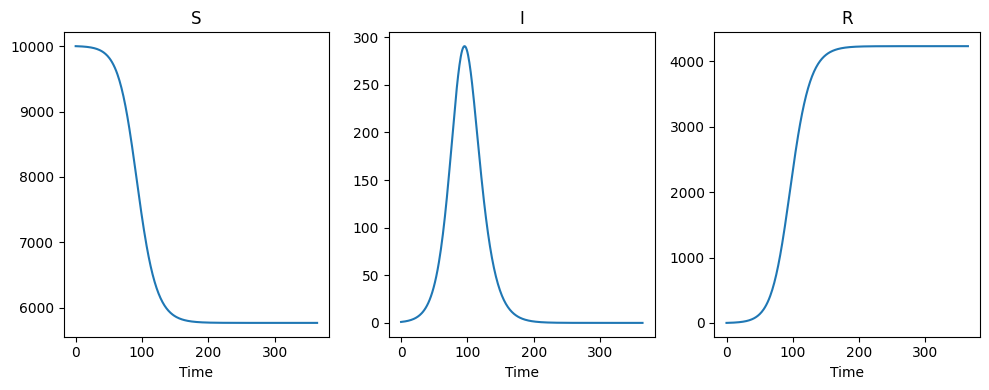

In [2]:
state_names = model.state_list

fig, axes = plt.subplots(1, 3, figsize=(10, 4))

for i in range(len(state_names)):
    axes[i].plot(t, solution[0].result.y[:, i])
    axes[i].set_title(state_names[i])
    axes[i].set_xlabel('Time')

plt.tight_layout()
plt.show()